In [22]:
import os
import sys

import numpy as np
import pandas as pd
import warnings

warnings.filterwarnings("ignore")
sys.path.append(os.path.abspath(os.path.join("modelling", '../..')))

from utility import plot

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from xgboost import XGBClassifier # Added XGBClassifier
from sklearn.ensemble import RandomForestClassifier # Added RandomForestClassifier

from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

In [23]:
SEED = 42
PLOT_DPI = 100

TRAIN_DATA_FILE = "../data/preprocessed_skab_dataset_fe_train.csv"
TRAIN_DATA_FILE = "../data/preprocessed_skab_dataset_train_undersampled_smote_fe.csv"
# TRAIN_DATA_FILE = "../data/preprocessed_skab_dataset_train_undersampled_adasyn_fe.csv"

TEST_DATA_FILE = "../data/preprocessed_skab_dataset_fe_test.csv"

USE_LDA = False
USE_FE = True

In [24]:
dataframe_train = pd.read_csv(TRAIN_DATA_FILE)
# dataframe_train.set_index(pd.to_datetime(dataframe_train.datetime), drop=True, inplace=True)
# dataframe_train.drop(columns=["datetime"], inplace=True)

if not USE_FE:
    og_columns = ["Accelerometer1RMS", "Accelerometer2RMS", "Current", "Pressure", "Temperature", "Thermocouple", "Voltage", "Volume Flow RateRMS", "anomaly", "description"]
    dataframe_train = dataframe_train.drop(columns=[col for col in dataframe_train.columns if col not in og_columns])

dataframe_train.head()

,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,Electrical_Resistence,Flow_Resistance,...,Temperature_Difference,Hydraulic_Power,Electrical_Power,Actual_Efficiency,Vibration_Intensity_Ratio,AccelerometerRMS_pu_Pressure,Engine_Temperature_pu_Power,Efficiency_Temperature_Difference_Ratio,anomaly,description
0,0.219595,0.267058,2.97205,1.074847,88.9166,28.9319,227.339,127.0000,76.492320,0.008463,...,59.9847,227.509732,574.313444,0.396142,0.822275,0.000462,0.154822,0.006604,0.0,No Anomaly
1,0.028225,0.042124,1.43210,1.401284,68.6462,24.7640,245.677,32.9805,171.550171,0.042488,...,43.8822,77.025248,299.058927,0.257559,0.670037,0.000036,0.229541,0.005869,0.0,No Anomaly
2,0.214053,0.259569,2.22898,1.730701,88.2787,29.6790,227.822,127.0000,102.209082,0.013628,...,58.5997,366.332439,431.639079,0.848701,0.824648,0.000437,0.204520,0.014483,0.0,No Anomaly
3,0.255422,0.294430,2.99871,1.074847,86.2073,28.8126,232.379,126.0000,77.492989,0.008531,...,57.3947,225.718316,592.311646,0.381080,0.867514,0.000597,0.145544,0.006640,0.0,No Anomaly
4,0.081667,0.129274,1.56118,0.733489,87.2407,22.1358,234.136,77.0000,149.973738,0.009526,...,65.1049,94.131282,310.699174,0.302966,0.631739,0.000137,0.280788,0.004654,0.0,No Anomaly


In [25]:
dataframe_test = pd.read_csv(TEST_DATA_FILE)
# dataframe_test.set_index(pd.to_datetime(dataframe_test.datetime), drop=True, inplace=True)
# dataframe_test.drop(columns=["datetime"], inplace=True)

if not USE_FE:
    og_columns = ["Accelerometer1RMS", "Accelerometer2RMS", "Current", "Pressure", "Temperature", "Thermocouple", "Voltage", "Volume Flow RateRMS", "anomaly", "description"]
    dataframe_test = dataframe_test.drop(columns=[col for col in dataframe_test.columns if col not in og_columns])

dataframe_test.head()

,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,Electrical_Resistence,Flow_Resistance,...,Temperature_Difference,Hydraulic_Power,Electrical_Power,Actual_Efficiency,Vibration_Intensity_Ratio,AccelerometerRMS_pu_Pressure,Engine_Temperature_pu_Power,Efficiency_Temperature_Difference_Ratio,description,anomaly
0,0.210323,0.262893,2.65864,1.074847,88.6217,29.3147,230.091,126.677,86.544624,0.008485,...,59.3070,226.931105,519.969766,0.436431,0.800033,0.000436,0.170436,0.007359,No Anomaly,0.0
1,0.028297,0.042536,0.81412,0.745430,68.0318,24.2354,232.174,32.000,285.184002,0.023295,...,43.7964,39.756362,160.664872,0.247449,0.665238,0.000038,0.423439,0.005650,No Anomaly,0.0
2,0.028185,0.041387,0.81061,1.073357,68.8750,24.7075,208.422,32.000,257.117479,0.033542,...,44.1675,57.245837,143.606614,0.398630,0.681015,0.000036,0.479609,0.009025,No Anomaly,0.0
3,0.027955,0.042217,1.12593,1.073357,68.9973,24.7679,235.556,27.000,209.210164,0.039754,...,44.2294,48.301175,225.436632,0.214256,0.662168,0.000044,0.306061,0.004844,Inlet Valve Malfunction,12.0
4,0.211749,0.272061,2.65451,1.402774,90.2739,27.8473,225.678,123.668,85.016820,0.011343,...,62.4266,289.130998,509.204832,0.567809,0.778314,0.000466,0.177284,0.009096,No Anomaly,0.0


In [26]:
scaler = StandardScaler()

values = scaler.fit_transform(dataframe_train.drop(columns=["anomaly", "description"]).values)

if USE_LDA:
    lda = LinearDiscriminantAnalysis()
    values = lda.fit_transform(values, dataframe_train.anomaly.to_numpy().ravel())
    dataframe_train_scaled = pd.DataFrame(values, columns=[f"Linear_Discriminant_{idx}" for idx in range(1, values.shape[1]+1)])
else:
    dataframe_train_scaled = pd.DataFrame(values, columns=dataframe_train.drop(columns=["anomaly", "description"]).columns)

dataframe_train_scaled = dataframe_train_scaled.assign(anomaly=dataframe_train.anomaly.values, description=dataframe_train.description.values)
dataframe_train_scaled

,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,Electrical_Resistence,Flow_Resistance,...,Temperature_Difference,Hydraulic_Power,Electrical_Power,Actual_Efficiency,Vibration_Intensity_Ratio,AccelerometerRMS_pu_Pressure,Engine_Temperature_pu_Power,Efficiency_Temperature_Difference_Ratio,anomaly,description
0,-0.330334,-0.313927,1.236586,-0.188610,0.725076,0.146169,-0.152574,0.654383,-0.744811,-0.174772,...,0.786938,0.462513,1.165554,-0.264070,0.200904,-0.203788,-0.759436,-0.420958,0.0,No Anomaly
1,-1.244971,-1.299616,-1.009370,1.307826,-2.237591,-1.273270,1.867961,-1.513511,0.633169,-0.002585,...,-2.009270,-1.171083,-0.834221,-0.945130,-1.469696,-0.236246,-0.047567,-0.628456,0.0,No Anomaly
2,-0.356821,-0.346745,0.152848,2.817920,0.631842,0.400604,-0.099355,0.654383,-0.372015,-0.148638,...,0.546432,1.969514,0.128998,1.960005,0.226947,-0.205639,-0.285951,1.804173,0.0,No Anomaly
3,-0.159102,-0.193980,1.275468,-0.188610,0.329092,0.105539,0.402748,0.631325,-0.730305,-0.174432,...,0.337183,0.443066,1.296314,-0.338090,0.697340,-0.193489,-0.847836,-0.410907,0.0,No Anomaly
4,-0.989547,-0.917715,-0.821112,-1.753445,0.480131,-2.168341,0.596340,-0.498513,0.320393,-0.169395,...,1.676064,-0.985387,-0.749653,-0.721979,-1.889965,-0.228541,0.440688,-0.971820,0.0,No Anomaly
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
315191,-1.249166,-1.304602,-1.389484,-2.015720,-2.018707,-1.420216,0.888304,-1.536963,1.076411,-0.110530,...,-1.674286,-1.616144,-1.293954,-1.459969,-1.500581,-0.236321,0.599874,-1.344074,13.0,Outlet Valve Malfunction
315192,-1.248400,-1.307080,-1.837579,-0.195439,-2.142214,-1.497146,0.345406,-1.606289,2.035416,-0.030017,...,-1.781800,-1.444898,-1.769510,-0.716219,-1.354676,-0.236067,1.641878,-0.385420,13.0,Outlet Valve Malfunction
315193,-1.248420,-1.315082,-1.664568,-0.008068,-2.250555,-1.447758,-0.026083,-1.606078,1.516297,-0.022935,...,-1.935703,-1.423300,-1.620123,-0.826001,-1.002505,-0.236200,1.187320,-0.489791,13.0,Outlet Valve Malfunction
315194,-1.248434,-1.307764,-2.086406,-0.195439,-2.235416,-1.477578,0.991127,-1.544793,3.114480,-0.045837,...,-1.902512,-1.393105,-1.988689,-0.227195,-1.327661,-0.236325,2.432920,0.275827,13.0,Outlet Valve Malfunction


In [27]:
values = scaler.transform(dataframe_test.drop(columns=["anomaly", "description"]).values)

if USE_LDA:
    values = lda.transform(values)
    dataframe_test_scaled = pd.DataFrame(values, columns=[f"Linear_Discriminant_{idx}" for idx in range(1, values.shape[1]+1)])
else:
    dataframe_test_scaled = pd.DataFrame(values, columns=dataframe_test.drop(columns=["anomaly", "description"]).columns)

dataframe_test_scaled = dataframe_test_scaled.assign(anomaly=dataframe_test.anomaly.values, description=dataframe_test.description.values)
dataframe_test_scaled

,Accelerometer1RMS,Accelerometer2RMS,Current,Pressure,Temperature,Thermocouple,Voltage,Volume Flow RateRMS,Electrical_Resistence,Flow_Resistance,...,Temperature_Difference,Hydraulic_Power,Electrical_Power,Actual_Efficiency,Vibration_Intensity_Ratio,AccelerometerRMS_pu_Pressure,Engine_Temperature_pu_Power,Efficiency_Temperature_Difference_Ratio,anomaly,description
0,-0.374648,-0.332179,0.779490,-0.188610,0.681974,0.276537,0.150650,0.646936,-0.599090,-0.174662,...,0.669255,0.456232,0.770737,-0.066071,-0.043170,-0.205716,-0.610677,-0.207793,0.0,No Anomaly
1,-1.244628,-1.297812,-1.910670,-1.698705,-2.327390,-1.453292,0.380161,-1.536119,2.280432,-0.099716,...,-2.024169,-1.575658,-1.839680,-0.994814,-1.522356,-0.236127,1.799774,-0.690400,0.0,No Anomaly
2,-1.245162,-1.302849,-1.915789,-0.195439,-2.204150,-1.292512,-2.236905,-1.536119,1.873573,-0.047856,...,-1.959727,-1.385800,-1.963611,-0.251846,-1.349225,-0.236215,2.334923,0.262865,0.0,No Anomaly
3,-1.246262,-1.299211,-1.455907,-0.195439,-2.186275,-1.271941,0.752800,-1.651408,1.179097,-0.016422,...,-1.948978,-1.482899,-1.369101,-1.157939,-1.556041,-0.235662,0.681467,-0.917965,12.0,Inlet Valve Malfunction
4,-0.367833,-0.292004,0.773466,1.314655,0.923455,-0.223207,-0.335588,0.577554,-0.621238,-0.160199,...,1.210975,1.131448,0.692527,0.579577,-0.281498,-0.203478,-0.545435,0.282696,0.0,No Anomaly
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7376,-1.250255,-1.309834,-1.426665,-0.195439,-2.095920,-1.199980,0.176322,-1.559177,1.059854,-0.042381,...,-1.878320,-1.405220,-1.376961,-0.996116,-1.343745,-0.236340,0.721781,-0.722101,12.0,Inlet Valve Malfunction
7377,-0.379844,-0.338954,0.595374,-0.188610,0.734781,0.228722,-0.641455,0.631325,-0.577702,-0.174432,...,0.756376,0.443066,0.478936,0.101049,-0.036878,-0.205906,-0.467574,-0.064652,0.0,No Anomaly
7378,-1.248453,-1.310222,-2.195271,-0.195439,-2.286597,-1.364030,0.031322,-1.535388,3.509585,-0.048024,...,-2.021217,-1.385184,-2.131564,0.126338,-1.222906,-0.236396,3.167025,0.779495,0.0,No Anomaly
7379,-0.218094,-0.224918,0.286632,1.314655,0.233037,0.334841,2.359598,0.663238,-0.291177,-0.161873,...,0.106141,1.225759,0.577885,0.755346,0.459883,-0.197186,-0.582630,0.754371,0.0,No Anomaly


In [28]:
X_train_scaled = dataframe_train.drop(columns=["anomaly", "description"]).values
y_train = dataframe_train["anomaly"].values.ravel()

X_test_scaled = dataframe_test.drop(columns=["anomaly", "description"]).values
y_test = dataframe_test["anomaly"].values.ravel()

In [29]:
combined = zip(dataframe_train.anomaly.values, dataframe_train.description.values)
sorted_pairs = sorted(combined, key=lambda pair: pair[0])

anomaly_ids = dict()
for i in sorted_pairs:
    anomaly_ids[i[0]] = i[1]

anomaly_names = [val for key, val in anomaly_ids.items()]

In [30]:
def format_cf(cf):
    tp = cf[0, 0]
    fp = np.sum(cf[1:, 0])
    fn = np.sum(cf[0, 1:])
    tn = np.sum(cf[1:, 1:])
    return np.array([[tp, fn], [fp, tn]])

### Logistic Regression

In [31]:
model = LogisticRegression(
                                solver='newton-cholesky', 
                                multi_class='ovr', 
                                C=20) # 'lbfgs' is a good general-purpose solver
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.5601


In [32]:
# plot.make_confusion_matrix(
#     confusion_matrix(y_test, y_pred),
#     categories=anomaly_names,
#     count=False,
#     cbar=False,
#     figsize=(20, 20)
# )

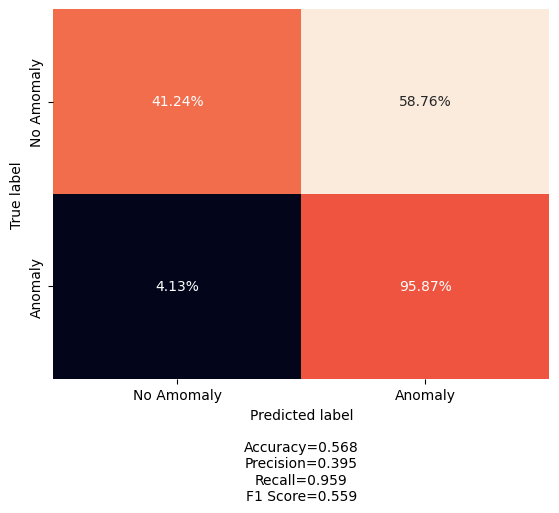

In [33]:
plot.make_confusion_matrix(
    format_cf(confusion_matrix(y_test, y_pred)),
    categories=["No Amomaly", "Anomaly",],
    count=False,
    cbar=False,
)

### Random Forest Classifier

In [34]:
model = RandomForestClassifier(n_estimators=100, random_state=SEED)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f}")

Model Accuracy: 0.9453


In [35]:
# plot.make_confusion_matrix(
#     confusion_matrix(y_test, y_pred),
#     categories=anomaly_names,
#     count=False,
#     cbar=False,
#     figsize=(20, 20)
# )

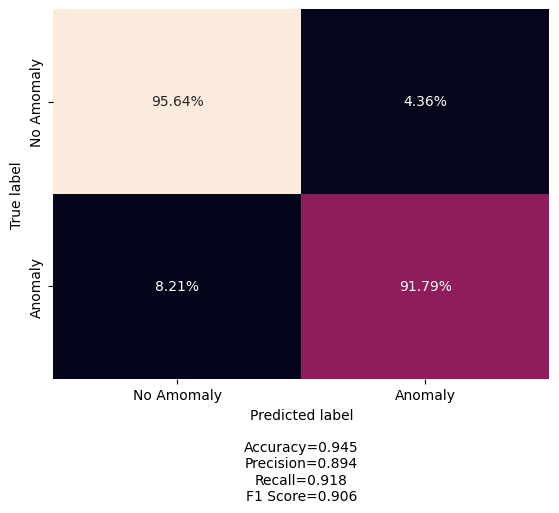

In [36]:
plot.make_confusion_matrix(
    format_cf(confusion_matrix(y_test, y_pred)),
    categories=["No Amomaly", "Anomaly",],
    count=False,
    cbar=False,
)

### XGBoost

In [37]:
model = XGBClassifier(objective='multi:softmax', num_class=len(anomaly_names), random_state=SEED)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.4f}")

Model Accuracy: 0.9295


In [38]:
# plot.make_confusion_matrix(
#     confusion_matrix(y_test, y_pred),
#     categories=anomaly_names,
#     count=False,
#     cbar=False,
#     figsize=(20, 20)
# )

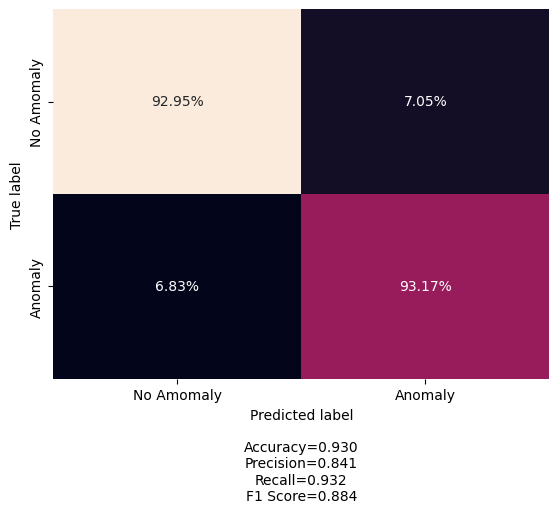

In [39]:
plot.make_confusion_matrix(
    format_cf(confusion_matrix(y_test, y_pred)),
    categories=["No Amomaly", "Anomaly",],
    count=False,
    cbar=False,
)

### SVM

In [40]:
# # 3. Instantiate and Train SVM
# svm_model = SVC(kernel='linear', C=5.0, probability=True) # Example with RBF kernel
# svm_model.fit(X_train_scaled, y_train)

# # 4. Make Predictions and Evaluate
# y_pred = svm_model.predict(X_test_scaled)
# accuracy = accuracy_score(y_test, y_pred)
# print(f"Model Accuracy: {accuracy:.4f}")

In [41]:
# plot.make_confusion_matrix(
#     confusion_matrix(y_test, y_pred),
#     categories=anomaly_names,
#     count=False,
#     cbar=False,
#     figsize=(20, 20)
# )

In [42]:
# plot.make_confusion_matrix(
#     format_cf(confusion_matrix(y_test, y_pred)),
#     categories=["No Amomaly", "Anomaly",],
#     count=False,
#     cbar=False,
# )